In [5]:
import sys
import torch
import matplotlib.pyplot as plt

In [6]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_IMAGES = 10

print("Device:", DEVICE)

Device: cuda


In [7]:
def latent_from_seed(
    seed,
    latent_dim,
    device
):

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    return torch.randn(
        1,
        latent_dim,
        generator=g,
        device=device
    )


def interpolate_latents(
    z_A,
    z_B,
    num_images=10
):

    ts = torch.linspace(
        0,
        1,
        num_images,
        device=z_A.device
    )

    latents = []

    for t in ts:

        z_t = (1 - t) * z_A + t * z_B
        latents.append(z_t)

    return torch.cat(
        latents,
        dim=0
    )


def generate_wgan(
    G,
    latent_vectors
):

    with torch.no_grad():

        generated = G(latent_vectors)

    return generated


def generate_stylegan(
    G,
    latent_vectors,
    truncation_psi=0.8
):

    with torch.no_grad():

        c = (
            torch.zeros(
                latent_vectors.shape[0],
                G.c_dim,
                device=latent_vectors.device
            )
            if G.c_dim > 0
            else None
        )

        generated = G(
            latent_vectors,
            c,
            truncation_psi=truncation_psi
        )

    return generated


def postprocess(images):

    images = (images + 1) / 2
    images = images.clamp(0, 1)

    return images


def run_wgan_interpolation(
    G,
    latent_dim,
    seed_A,
    seed_B,
    num_images=10
):

    z_A = latent_from_seed(
        seed_A,
        latent_dim,
        DEVICE
    )

    z_B = latent_from_seed(
        seed_B,
        latent_dim,
        DEVICE
    )

    latent_vectors = interpolate_latents(
        z_A,
        z_B,
        num_images
    )

    generated = generate_wgan(
        G,
        latent_vectors
    )

    generated = postprocess(
        generated
    )

    return generated


def run_stylegan_interpolation(
    G,
    latent_dim,
    seed_A,
    seed_B,
    truncation_psi=0.8,
    num_images=10
):

    z_A = latent_from_seed(
        seed_A,
        latent_dim,
        DEVICE
    )

    z_B = latent_from_seed(
        seed_B,
        latent_dim,
        DEVICE
    )

    latent_vectors = interpolate_latents(
        z_A,
        z_B,
        num_images
    )

    generated = generate_stylegan(
        G,
        latent_vectors,
        truncation_psi
    )

    generated = postprocess(
        generated
    )

    return generated

In [8]:
from wgan_gp_cats.src.models.wgan_gp import Generator

WGAN_LATENT_DIM = 128

WGAN_CHECKPOINT = (
    "../wgan_gp_cats/scripts/checkpoints/"
    "wgan_gp_l10_n3_z128/"
    "wgan_gp_epoch_050.pt"
)

G_wgan = Generator(
    latent_dim=WGAN_LATENT_DIM
).to(DEVICE)

checkpoint = torch.load(
    WGAN_CHECKPOINT,
    map_location=DEVICE
)

G_wgan.load_state_dict(
    checkpoint["generator"]
)

G_wgan.eval()

print("WGAN loaded")

WGAN loaded


In [9]:
sys.path.append(
    "../stylegan2-ada-pytorch"
)

import legacy

STYLEGAN_PKL = (
    "../stylegan_cats/outputs_cats/"
    "network-snapshot-001000.pkl"
)

STYLEGAN_LATENT_DIM = 512
TRUNCATION_PSI = 0.8

print("Loading StyleGAN...")

with open(STYLEGAN_PKL, "rb") as f:

    network = legacy.load_network_pkl(f)

G_stylegan = network["G_ema"].to(DEVICE)

G_stylegan.eval()

print("StyleGAN loaded")

Loading StyleGAN...
StyleGAN loaded


In [10]:
wgan_images = run_wgan_interpolation(
    G=G_wgan,
    latent_dim=WGAN_LATENT_DIM,
    seed_A=6406,
    seed_B=6557,
    num_images=NUM_IMAGES
)

In [11]:
stylegan_images = run_stylegan_interpolation(
    G=G_stylegan,
    latent_dim=STYLEGAN_LATENT_DIM,
    seed_A=62,
    seed_B=63,
    truncation_psi=TRUNCATION_PSI,
    num_images=NUM_IMAGES
)

WGAN-GP Model:
Seeds: 6406 → 6557
Generated images: 10


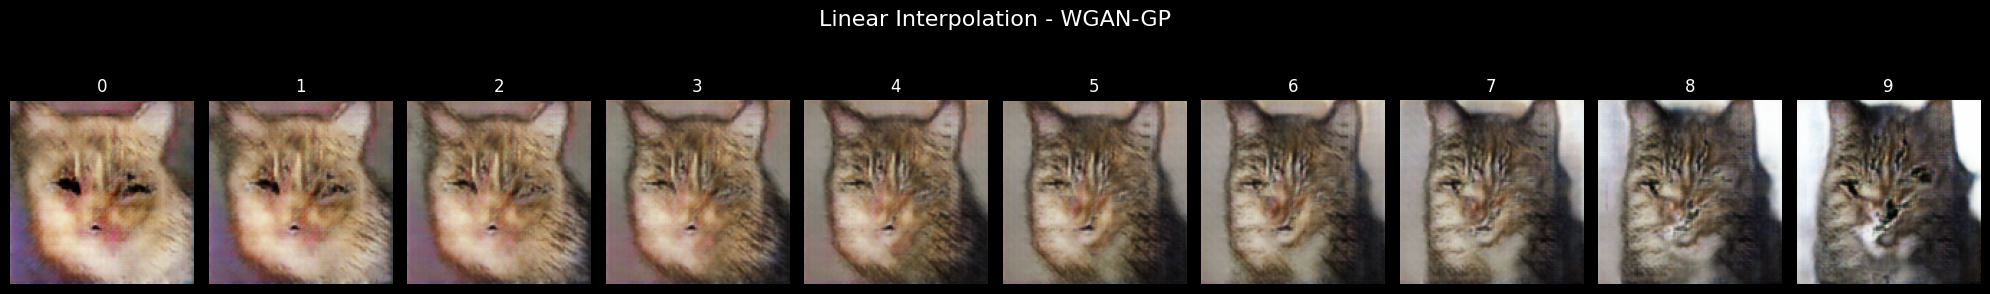


StyleGAN2 Model:
Seeds: 62 → 63
Generated images: 10


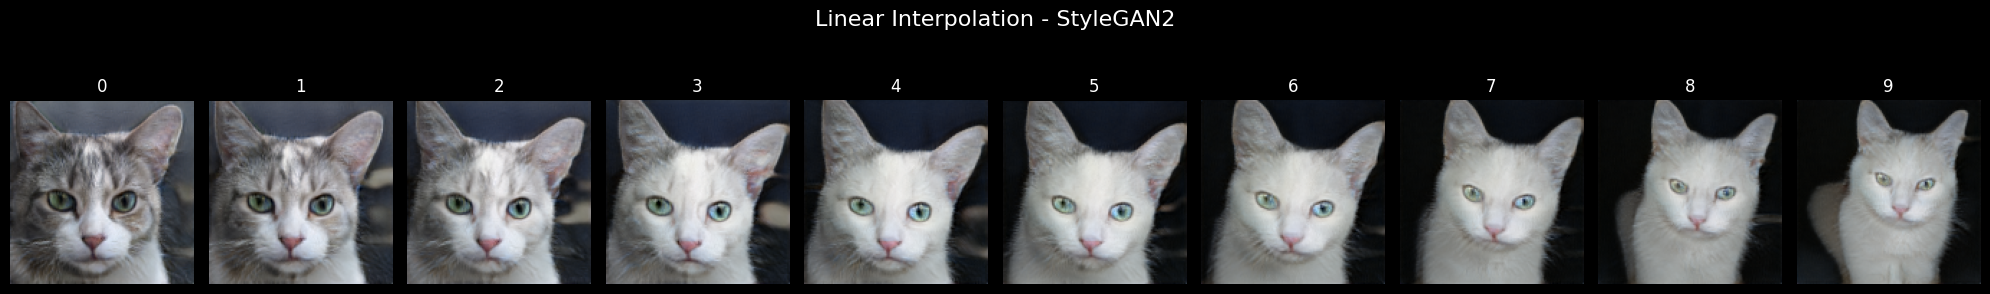


Saved:
 - wgan_linear_interpolation.png
 - stylegan_linear_interpolation.png


In [13]:
# ==================================================
# WGAN-GP
# ==================================================

print("WGAN-GP Model:")
print(f"Seeds: 6406 → 6557")
print(f"Generated images: {NUM_IMAGES}")

fig, axes = plt.subplots(
    1,
    NUM_IMAGES,
    figsize=(20, 3)
)

for i in range(NUM_IMAGES):

    img = (
        wgan_images[i]
        .cpu()
        .permute(1, 2, 0)
    )

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{i}")

fig.suptitle(
    "Linear Interpolation - WGAN-GP",
    fontsize=16,
    y=1.05
)

plt.tight_layout()

plt.savefig(
    "wgan_linear_interpolation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================
# STYLEGAN2
# ==================================================

print("\nStyleGAN2 Model:")
print(f"Seeds: 62 → 63")
print(f"Generated images: {NUM_IMAGES}")

fig, axes = plt.subplots(
    1,
    NUM_IMAGES,
    figsize=(20, 3)
)

for i in range(NUM_IMAGES):

    img = (
        stylegan_images[i]
        .cpu()
        .permute(1, 2, 0)
    )

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{i}")

fig.suptitle(
    "Linear Interpolation - StyleGAN2",
    fontsize=16,
    y=1.05
)

plt.tight_layout()

plt.savefig(
    "stylegan_linear_interpolation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(" - wgan_linear_interpolation.png")
print(" - stylegan_linear_interpolation.png")

Because the latent representation consists of discrete codebook indices, direct linear interpolation is not possible. Instead, intermediate representations are generated by progressively replacing latent tokens from one sample with tokens from another sample according to a mixing coefficient t.